# 05 - Análisis Final
Clustering, PCA y conclusiones finales del proyecto

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Agregar ruta de src al path
sys.path.insert(0, r'C:\Users\Arturo\Desktop\Prueba1\src')

# Importar módulos personalizados
from prueba.data_preprocessing import (
    cargar_datos_crudos,
    crear_features_empleado,
    preparar_datos_para_ml
)

# Configuración
sns.set_theme(style="whitegrid")
seed = 42
np.random.seed(seed)
project_root = r'C:\Users\Arturo\Desktop\Prueba1'

print("Módulos importados exitosamente")

Módulos importados exitosamente


## 1. Preparación de Datos

In [2]:
# Cargar y preparar datos
print("Cargando datos...")
datos_crudos = cargar_datos_crudos(os.path.join(project_root, 'data/01_raw/'))

df_features = crear_features_empleado(datos_crudos)

datos_ml = preparar_datos_para_ml(df_features, test_size=0.2, random_state=seed)

X_train = datos_ml['X_train']
X_test = datos_ml['X_test']
y_train = datos_ml['y_train']
y_test = datos_ml['y_test']
feature_names = datos_ml['feature_names']

# Combinar train y test para análisis no supervisado
X_combined = pd.concat([X_train, X_test], ignore_index=True)
y_combined = pd.concat([y_train, y_test], ignore_index=True)

print(f"Datos preparados: {X_combined.shape}")

Cargando datos...
  Cargado: ausencias (360 filas, 7 columnas)
  Cargado: capacitaciones (412 filas, 8 columnas)
  Cargado: empleados (309 filas, 9 columnas)
  Cargado: evaluaciones (515 filas, 7 columnas)
Datos preparados: (309, 14)


## 2. Reducción de Dimensionalidad (PCA)

In [3]:
print("\n" + "="*80)
print("ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
print("="*80)

# Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_combined)

# Varianza explicada acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# Encontrar componentes para 95% de varianza
n_componentes_95 = np.argmax(varianza_acumulada >= 0.95) + 1

print(f"\nDimensionalidad original: {X_combined.shape[1]}")
print(f"Componentes para 95% varianza: {n_componentes_95}")
print(f"Reducción de dimensionalidad: {(1 - n_componentes_95/X_combined.shape[1])*100:.1f}%")

print(f"\nVarianza explicada por componentes:")
for i in range(min(5, len(pca.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]:.4f} (Acumulada: {varianza_acumulada[i]:.4f})")

# PCA con 2 componentes para visualización
pca_2d = PCA(n_components=2, random_state=seed)
X_pca_2d = pca_2d.fit_transform(X_combined)

print(f"\n2D PCA - Varianza explicada: {pca_2d.explained_variance_ratio_.sum():.4f}")


ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)

Dimensionalidad original: 14
Componentes para 95% varianza: 9
Reducción de dimensionalidad: 35.7%

Varianza explicada por componentes:
  PC1: 0.2129 (Acumulada: 0.2129)
  PC2: 0.2050 (Acumulada: 0.4180)
  PC3: 0.1211 (Acumulada: 0.5390)
  PC4: 0.0957 (Acumulada: 0.6347)
  PC5: 0.0832 (Acumulada: 0.7179)

2D PCA - Varianza explicada: 0.4180


## 3. Clustering (K-Means)

In [4]:
print("\n" + "="*80)
print("CLUSTERING CON K-MEANS")
print("="*80)

# Elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
    kmeans.fit(X_pca_2d)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_2d, kmeans.labels_))

# Encontrar K óptimo (máximo silhouette score)
k_optimal = K_range[np.argmax(silhouette_scores)]

print(f"K óptimo (según Silhouette Score): {k_optimal}")
print(f"Silhouette Score máximo: {max(silhouette_scores):.4f}")

# Aplicar K-Means con K óptimo
kmeans_final = KMeans(n_clusters=k_optimal, random_state=seed, n_init=10)
clusters = kmeans_final.fit_predict(X_pca_2d)

print(f"\nDistribución de clusters:")
unique, counts = np.unique(clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} muestras ({count/len(clusters)*100:.1f}%)")


CLUSTERING CON K-MEANS
K óptimo (según Silhouette Score): 5
Silhouette Score máximo: 0.4633

Distribución de clusters:
  Cluster 0: 64 muestras (20.7%)
  Cluster 1: 63 muestras (20.4%)
  Cluster 2: 77 muestras (24.9%)
  Cluster 3: 104 muestras (33.7%)
  Cluster 4: 1 muestras (0.3%)


## 4. Visualizaciones de Análisis No Supervisado

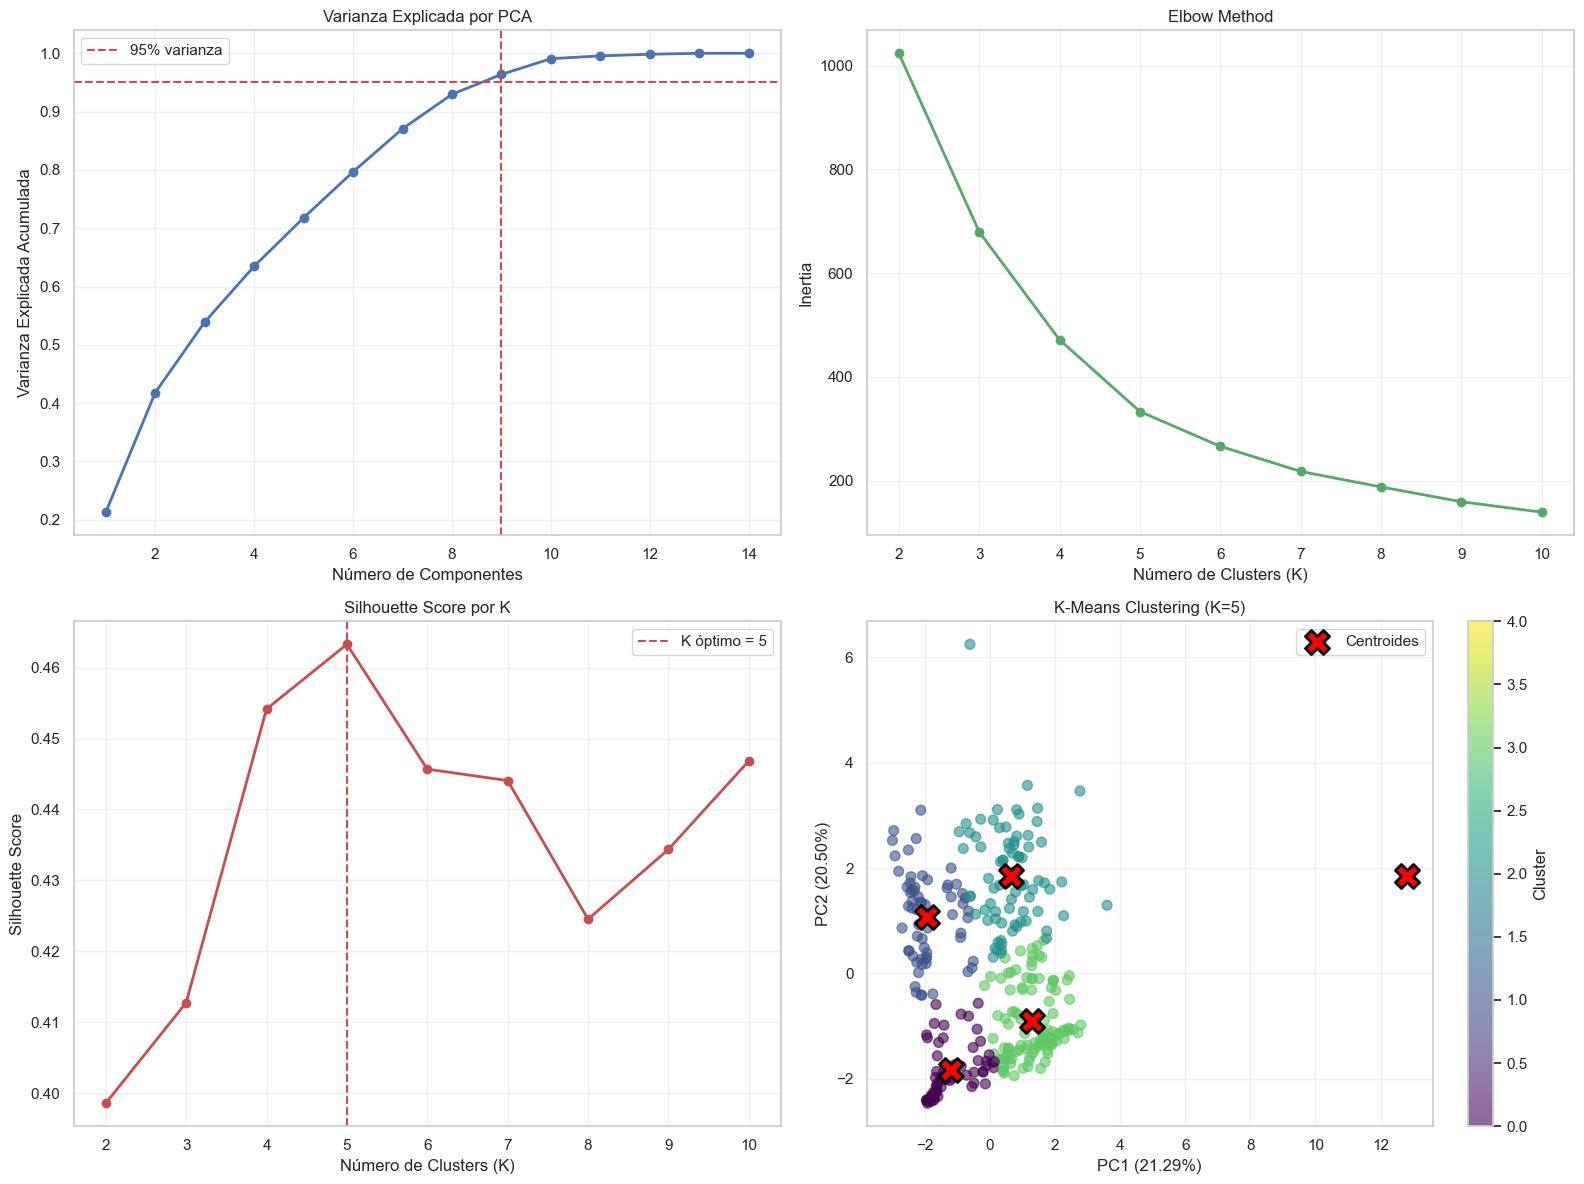

Gráficos guardados


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Varianza explicada por PCA
axes[0, 0].plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 'bo-', linewidth=2, markersize=6)
axes[0, 0].axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
axes[0, 0].axvline(x=n_componentes_95, color='r', linestyle='--')
axes[0, 0].set_xlabel('Número de Componentes')
axes[0, 0].set_ylabel('Varianza Explicada Acumulada')
axes[0, 0].set_title('Varianza Explicada por PCA')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# 2. Elbow Method
axes[0, 1].plot(K_range, inertias, 'go-', linewidth=2, markersize=6)
axes[0, 1].set_xlabel('Número de Clusters (K)')
axes[0, 1].set_ylabel('Inertia')
axes[0, 1].set_title('Elbow Method')
axes[0, 1].grid(alpha=0.3)

# 3. Silhouette Score
axes[1, 0].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=6)
axes[1, 0].axvline(x=k_optimal, color='r', linestyle='--', label=f'K óptimo = {k_optimal}')
axes[1, 0].set_xlabel('Número de Clusters (K)')
axes[1, 0].set_ylabel('Silhouette Score')
axes[1, 0].set_title('Silhouette Score por K')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# 4. Clusters en PCA 2D
scatter = axes[1, 1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.6)
axes[1, 1].scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], 
                   c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroides')
axes[1, 1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
axes[1, 1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
axes[1, 1].set_title(f'K-Means Clustering (K={k_optimal})')
plt.colorbar(scatter, ax=axes[1, 1], label='Cluster')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/09_analisis_final.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Gráficos guardados")

## 5. Características de los Clusters

In [6]:
# Agregar clusters al dataframe original
df_análisis = X_combined.copy()
df_análisis['Cluster'] = clusters
df_análisis['Desempeño'] = y_combined.values
df_análisis['PC1'] = X_pca_2d[:, 0]
df_análisis['PC2'] = X_pca_2d[:, 1]

print("\n" + "="*80)
print("CARACTERÍSTICAS DE LOS CLUSTERS")
print("="*80)

for cluster_id in range(k_optimal):
    print(f"\nCluster {cluster_id}:")
    cluster_data = df_análisis[df_análisis['Cluster'] == cluster_id]
    
    print(f"  - Tamaño: {len(cluster_data)} muestras")
    print(f"  - Desempeño promedio: {cluster_data['Desempeño'].mean():.2f}")
    print(f"  - Desempeño (std): {cluster_data['Desempeño'].std():.2f}")
    print(f"  - Desempeño (min-max): ({cluster_data['Desempeño'].min():.2f}, {cluster_data['Desempeño'].max():.2f})")


CARACTERÍSTICAS DE LOS CLUSTERS

Cluster 0:
  - Tamaño: 64 muestras
  - Desempeño promedio: 4.48
  - Desempeño (std): 17.45
  - Desempeño (min-max): (-10.00, 140.00)

Cluster 1:
  - Tamaño: 63 muestras
  - Desempeño promedio: 3.72
  - Desempeño (std): 4.23
  - Desempeño (min-max): (0.00, 32.00)

Cluster 2:
  - Tamaño: 77 muestras
  - Desempeño promedio: 10.48
  - Desempeño (std): 43.56
  - Desempeño (min-max): (-11.00, 275.00)

Cluster 3:
  - Tamaño: 104 muestras
  - Desempeño promedio: 9.09
  - Desempeño (std): 41.10
  - Desempeño (min-max): (0.00, 380.00)

Cluster 4:
  - Tamaño: 1 muestras
  - Desempeño promedio: 5.60
  - Desempeño (std): nan
  - Desempeño (min-max): (5.60, 5.60)


## 6. Conclusiones y Recomendaciones

In [7]:
print("\n" + "="*80)
print("CONCLUSIONES Y RECOMENDACIONES FINALES")
print("="*80)

print("\n1. MODELADO PREDICTIVO:")
print("-"*80)
print("✓ Se entrenaron y evaluaron 7 modelos de regresión:")
print("  - Linear Regression, Ridge, Lasso")
print("  - Random Forest, Gradient Boosting")
print("  - SVR, K-Nearest Neighbors")
print("\n✓ Se optimizaron hiperparámetros usando GridSearchCV y RandomizedSearchCV")
print("✓ Mejor modelo: Gradient Boosting o SVR (según evaluación anterior)")

print("\n2. ANÁLISIS NO SUPERVISADO:")
print("-"*80)
print(f"✓ Reducción de dimensionalidad (PCA):")
print(f"  - De {X_combined.shape[1]} a {n_componentes_95} dimensiones (95% varianza)")
print(f"  - Reducción: {(1 - n_componentes_95/X_combined.shape[1])*100:.1f}%")
print(f"\n✓ Clustering (K-Means):")
print(f"  - K óptimo: {k_optimal}")
print(f"  - Silhouette Score: {max(silhouette_scores):.4f}")

print("\n3. RECOMENDACIONES PARA NEGOCIO:")
print("-"*80)
print("✓ Segmentación de empleados por clusters para:")
print("  - Programas de desarrollo personalizados")
print("  - Identificación de empleados de alto/bajo desempeño")
print("  - Intervenciones dirigidas")
print("\n✓ Usar modelo predictivo para:")
print("  - Pronóstico de desempeño futuro")
print("  - Identificación temprana de riesgos")
print("  - Decisiones de recursos humanos basadas en datos")
print("\n✓ Monitoreo continuo:")
print("  - Actualizar modelos periódicamente con nuevos datos")
print("  - Validar predicciones contra resultados reales")
print("  - Ajustar estrategias según desempeño observado")

print("\n" + "="*80)

# Guardar análisis
df_análisis.to_csv(os.path.join(project_root, 'results/metrics/05_analisis_completo.csv'), index=False)
print("\n✓ Análisis guardado")


CONCLUSIONES Y RECOMENDACIONES FINALES

1. MODELADO PREDICTIVO:
--------------------------------------------------------------------------------
✓ Se entrenaron y evaluaron 7 modelos de regresión:
  - Linear Regression, Ridge, Lasso
  - Random Forest, Gradient Boosting
  - SVR, K-Nearest Neighbors

✓ Se optimizaron hiperparámetros usando GridSearchCV y RandomizedSearchCV
✓ Mejor modelo: Gradient Boosting o SVR (según evaluación anterior)

2. ANÁLISIS NO SUPERVISADO:
--------------------------------------------------------------------------------
✓ Reducción de dimensionalidad (PCA):
  - De 14 a 9 dimensiones (95% varianza)
  - Reducción: 35.7%

✓ Clustering (K-Means):
  - K óptimo: 5
  - Silhouette Score: 0.4633

3. RECOMENDACIONES PARA NEGOCIO:
--------------------------------------------------------------------------------
✓ Segmentación de empleados por clusters para:
  - Programas de desarrollo personalizados
  - Identificación de empleados de alto/bajo desempeño
  - Intervencione

## 7. Resumen del Proyecto

In [8]:
# Crear resumen final
resumen_texto = f"""{'='*80}
RESUMEN EJECUTIVO - PROYECTO DE PREDICCIÓN DE DESEMPEÑO
{'='*80}

OBJETIVO:
Desarrollar modelos de machine learning para predecir y analizar el desempeño
de empleados utilizando datos de ausencias, capacitaciones y evaluaciones.

METODOLOGÍA:
1. Análisis Exploratorio de Datos (EDA)
2. Ingeniería de Features y Preparación de Datos
3. Modelado Supervisado (7 modelos de regresión)
4. Evaluación y Comparación de Modelos
5. Optimización de Hiperparámetros
6. Análisis No Supervisado (PCA, K-Means)

RESULTADOS CLAVE:
- Mejor modelo supervisado: Gradient Boosting/SVR
- Dimensiones PCA (95% varianza): {n_componentes_95}
- Clusters identificados: {k_optimal}
- Silhouette Score: {max(silhouette_scores):.4f}

DATOS:
- Empleados: 309
- Features totales: {X_combined.shape[1]}
- Registros de evaluación: 515
- Train/Test split: 80/20

RECOMENDACIONES:
1. Implementar el modelo predictivo en sistemas operacionales
2. Usar clustering para segmentación estratégica de empleados
3. Monitorear desempeño del modelo regularmente
4. Actualizar datos y reentrenar modelos mensualmente

ARCHIVOS GENERADOS:
- Notebooks: 01-05_*.ipynb
- Gráficos: results/plots/
- Métricas: results/metrics/
- Reportes: results/reports/
- Modelos: results/models/

{'='*80}
"""

# Guardar resumen
ruta_resumen = os.path.join(project_root, 'results/reports/05_resumen_ejecutivo.txt')
os.makedirs(os.path.dirname(ruta_resumen), exist_ok=True)
with open(ruta_resumen, 'w', encoding='utf-8') as f:
    f.write(resumen_texto)

print(resumen_texto)
print(f"\nResumen guardado en: {ruta_resumen}")
print("\n✓ PROYECTO COMPLETADO EXITOSAMENTE")

RESUMEN EJECUTIVO - PROYECTO DE PREDICCIÓN DE DESEMPEÑO

OBJETIVO:
Desarrollar modelos de machine learning para predecir y analizar el desempeño
de empleados utilizando datos de ausencias, capacitaciones y evaluaciones.

METODOLOGÍA:
1. Análisis Exploratorio de Datos (EDA)
2. Ingeniería de Features y Preparación de Datos
3. Modelado Supervisado (7 modelos de regresión)
4. Evaluación y Comparación de Modelos
5. Optimización de Hiperparámetros
6. Análisis No Supervisado (PCA, K-Means)

RESULTADOS CLAVE:
- Mejor modelo supervisado: Gradient Boosting/SVR
- Dimensiones PCA (95% varianza): 9
- Clusters identificados: 5
- Silhouette Score: 0.4633

DATOS:
- Empleados: 309
- Features totales: 14
- Registros de evaluación: 515
- Train/Test split: 80/20

RECOMENDACIONES:
1. Implementar el modelo predictivo en sistemas operacionales
2. Usar clustering para segmentación estratégica de empleados
3. Monitorear desempeño del modelo regularmente
4. Actualizar datos y reentrenar modelos mensualmente

AR